#### **OBSERVATIONS:**

1.  The main objective of the problem statement is to classify the type of the breast cancer by constructing a Single Layered Neural Networks.

2.  Using Single Layered Neural Networks, we need to predict the type of the breast cancer for a particular test data.


#### **Step 1: Import all the necessary libraries**

In [412]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

from    sklearn.datasets        import load_breast_cancer
from    sklearn.model_selection import train_test_split
from    sklearn.preprocessing   import StandardScaler

from    tensorflow.keras.models import Sequential
from    tensorflow.keras.layers import Dense

#### **OBSERVATIONS:**

1.  Sequential ----->  It is used to construct a Sequential model of ann.

2.  Dense ---------->  It is used to build a dense layer.

#### **Step 2: Load the dataset**

In [413]:
#### Extract the data
data = load_breast_cancer()

#### construct the dataframe from the data
df = pd.DataFrame(data.data, columns=data.feature_names)

#### Adding the target to the dataset
df['target'] = data.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


#### **OBSERVATIONS:**

1.  The input features of the dataset ranges from mean radius .... worst fractal dimensions.

2.  The output feature of the dataset is the target.

#### **Step 3: Perform the Data Exploration:**

In [414]:
#### get the first five rows of the dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [415]:
#### get the last five rows of the dataset
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [416]:
#### get the length of the dataframe
print("Length of the dataframe is:", len(df))

Length of the dataframe is: 569


In [417]:
#### get the columns used in the dataframe
print("Columns used in the dataframe is:", df.columns)

Columns used in the dataframe is: Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [418]:
#### get the information about the columns used in the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### **OBSERVATIONS:**

1.  The independent features in the dataset are all floating point in nature.

2.  The dependent feature in the dataset is target.

In [419]:
#### get the descriptive statistical summary about the columns used in the dataset
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### **OBSERVATIONS:**

1.  The above columns are all numerical in nature that explains about the statistical summary for each in the dataset.

#### **Step 4: Perform the Data Cleaning**

In [420]:
#### To check for all the NULL records in the dataframe
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


#### **OBSERVATIONS:**

1.  There are no NULL records in the dataset.

In [421]:
#### To check for the duplicate records in the dataset
df[df.duplicated()]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


#### **OBSERVATIONS:**

1.  There are no duplicate records in the dataset.

#### **Step 5: Divide the dataset into independent and dependent features**

In [422]:
#### independent features
X = df.drop(columns='target',axis=1)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [423]:
#### dependent features
Y = df['target']
Y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


#### **Step 6: Divide the independent and dependent features into training and testing data**

In [424]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [425]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.03,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.54,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,15.28,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.032630,0.1727,0.06317,...,17.80,28.03,113.80,973.1,0.1301,0.32990,0.36300,0.12260,0.3175,0.09772
300,19.53,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.106200,0.1792,0.06552,...,25.93,26.24,171.10,2053.0,0.1495,0.41160,0.61210,0.19800,0.2968,0.09929
509,15.46,23.95,103.80,731.3,0.11830,0.18700,0.20300,0.085200,0.1807,0.07083,...,17.11,36.33,117.70,909.4,0.1732,0.49670,0.59110,0.21630,0.3013,0.10670
230,17.05,19.08,113.40,895.0,0.11410,0.15720,0.19100,0.109000,0.2131,0.06325,...,19.59,24.89,133.50,1189.0,0.1703,0.39340,0.50180,0.25430,0.3109,0.09061


In [426]:
X_test

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20.26,23.03,132.40,1264.0,0.09078,0.13130,0.14650,0.08683,0.2095,0.05649,...,24.22,31.59,156.10,1750.0,0.1190,0.35390,0.4098,0.15730,0.3689,0.08368
128,15.10,16.39,99.58,674.5,0.11500,0.18070,0.11380,0.08534,0.2001,0.06467,...,16.11,18.33,105.90,762.6,0.1386,0.28830,0.1960,0.14230,0.2590,0.07779
257,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,17.73,22.66,119.80,928.8,0.1765,0.45030,0.4429,0.22290,0.3258,0.11910
228,12.62,23.97,81.35,496.4,0.07903,0.07529,0.05438,0.02036,0.1514,0.06019,...,14.20,31.31,90.67,624.0,0.1227,0.34540,0.3911,0.11800,0.2826,0.09585


In [427]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (455, 30)
Shape of the input testing  data is: (114, 30)


In [428]:
Y_train

,target
546,1
432,0
174,1
221,1
289,1
...,...
184,0
300,0
509,0
230,0


In [429]:
Y_test

,target
256,0
428,1
501,0
363,1
564,0
...,...
95,0
128,1
257,0
228,1


In [430]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (455,)
Shape of the output testing  data is: (114,)


#### **OBSERVATIONS:**

1.  The dataset is divided into the training and testing data.

#### **Step 7: Perform Feature Scaling on the inputs**

In [431]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

#### using the object of scalar, transform the inputs
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

In [432]:
X_train_scaled

array([[-1.07200079, -0.6584246 , -1.0880801 , ..., -1.35052668,
        -0.35265805, -0.54138003],
       [ 1.74874285,  0.06650173,  1.75115682, ...,  1.54991557,
         0.19107787, -0.1737386 ],
       [-0.97473376, -0.93112416, -0.99770871, ..., -1.70744192,
        -0.307734  , -1.21303263],
       ...,
       [ 0.39844772,  1.06867262,  0.50751384, ...,  1.53492543,
         0.16164487,  1.23754763],
       [ 0.85331409, -0.0380331 ,  0.9054796 , ...,  2.10455077,
         0.31035897,  0.36249578],
       [-0.91179628, -0.82431683, -0.87666079, ..., -0.51332734,
        -0.50756857,  1.30824791]])

In [433]:
X_test_scaled

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

#### **OBSERVATIONS:**

1.  All the input data has been scaled in one range between 0 to 1.

In [434]:
X_test_scaled.shape

(114, 30)

In [435]:
Y_test.shape

(114,)

#### **Step 8: Construct the Single Layered Neural Network**

In [436]:
model = Sequential([
    #### create the output layer
    Dense(1,activation='sigmoid',input_dim=X_train.shape[1])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### **OBSERVATIONS:**

1.  The Sequential model has been constructed with only one dense layer for the output.

    (a.) This dense layer contains the following:-

        (i.)  input_dim = It specifies the total number of input features.

        (ii) activation = 'sigmoid'. The dataset is a binary classification data which is used to solve the binary classification problem.

        (iii) Only one neuron is present in the output layer of the Sequential layer.

#### **Step 9: Compile the model**

In [437]:
model.compile(
    optimizer = 'adam'                      ,
    loss      = 'binary_crossentropy'       ,
    metrics   = ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been made ready for the training with the following parameters:-

    (a.)  optimizer = 'adam'. It is used to update the weights during the backpropogation.

    (b.)  loss = 'binary_crossentropy' . It is used to solve the binary classification problem

    (c.)  metrics = ['accuracy'] . It is used to evaluate the performance of the model.

#### **Step 10: Train the model**

In [438]:
history = model.fit(
    X_train_scaled                                      ,
    Y_train                                             ,
    epochs              =        100                    ,
    batch_size          =        32                     ,
    validation_split    =        0.2                    ,
    verbose             =         1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4945 - loss: 0.7744 - val_accuracy: 0.5934 - val_loss: 0.6621
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5769 - loss: 0.6947 - val_accuracy: 0.6593 - val_loss: 0.5969
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6209 - loss: 0.6263 - val_accuracy: 0.7582 - val_loss: 0.5419
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6813 - loss: 0.5685 - val_accuracy: 0.7582 - val_loss: 0.4956
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7115 - loss: 0.5197 - val_accuracy: 0.7912 - val_loss: 0.4563
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7610 - loss: 0.4781 - val_accuracy: 0.8571 - val_loss: 0.4225
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8214 - loss: 0.4433 - val_accuracy: 0.8571 - val_loss: 0.3940
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8434 - loss: 0.4138 - val_accuracy: 0.8571 - 

#### **OBSERVATIONS:**

1.  The model has been trained with the following parameters:--

      (a.)  X_train_scaled, Y_train -------> Input training data

      (b.)  epochs = 100  ------------->  No of iterations needed to train the model

      (c.)  batch_size = 32 ----------->  32 samples of data is considered in each batch in the model training.

      (d.)  validation_split = 0.2--------> To prevent overfitting

      (e.)  verbose = 1 ----------> Amount of the information printed during the model training.

2.   From the model training, it is seen that the training and the validation accuracy has increased while the training and validation loss has reduced.

3. So the model is working fine.

#### **Step 11: Evaluate the model**

In [439]:
X_test_scaled

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

In [440]:
Y_test

,target
256,0
428,1
501,0
363,1
564,0
...,...
95,0
128,1
257,0
228,1


In [441]:
loss,accuracy = model.evaluate(
    X_test_scaled                               ,
    Y_test
)

print("Loss is:", loss)
print("Accuracy is:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.1129 
Loss is: 0.11287746578454971
Accuracy is: 0.9649122953414917


#### **Step 12: Visualize the Training and Validation Loss**

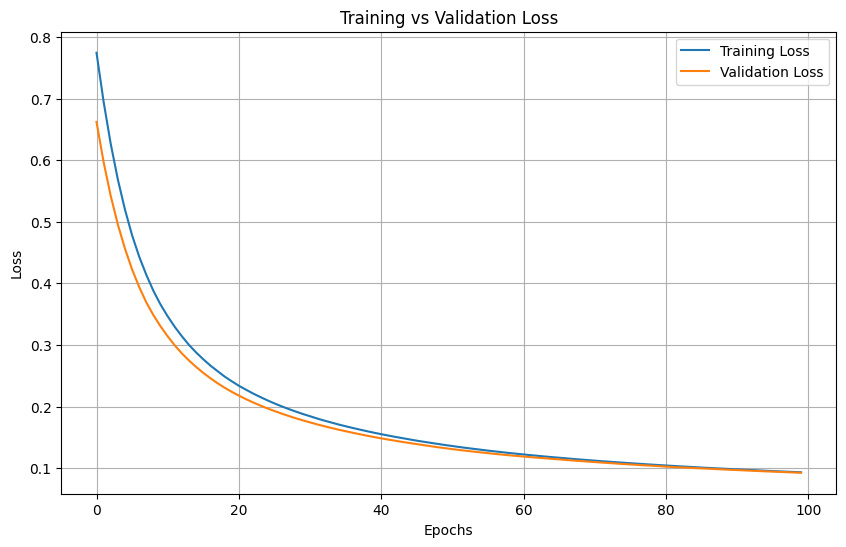

In [442]:
plt.figure(figsize=(10,6))

#### plot the training loss
plt.plot(history.history['loss'], label = 'Training Loss')
#### plot the validation loss
plt.plot(history.history['val_loss'], label = 'Validation Loss')
#### specify the x axis of the graph
plt.xlabel("Epochs")
#### specify the y axis of the graph
plt.ylabel("Loss")
#### give the title of the graph
plt.title("Training vs Validation Loss")
#### give the legend of the graph
plt.legend()
### display the grid of the graph
plt.grid()
#### display the graph
plt.show()

#### **OBSERVATIONS:**

1.  With the increase in epochs, both the training and validation loss decreases.

#### **Step 13: Perform the predictions**

In [443]:
Y_pred = model.predict(X_test_scaled)

Y_pred = (Y_pred > 0.5).astype(int)

Y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
    

#### **Step 14: Get the overall accuracy of the model**

In [444]:
from sklearn.metrics import accuracy_score

ac = accuracy_score(Y_test, Y_pred) * 100.0
print("Accuracy score of the model is:", ac)

Accuracy score of the model is: 96.49122807017544


#### **Step 15: Test whether the cancer is Malignant or benign based on the sample data**

In [445]:
#### define the sample data
sample=df.iloc[[568]]
#### remove the output from the sample data
sample = sample.drop(columns='target',axis=1)
print(sample)

#### scale the sample data
scaled_data = sc.transform(sample)
print(scaled_data)

#### perform the predictions on the scaled data
prediction = model.predict(scaled_data)
prediction = (prediction > 0.5).astype(int)
print(prediction)

if(prediction[0]==1):
  print("Malignant")
else:
  print("Benign")

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
568           0.04362             0.0                  0.0         0.1587   

     mean fractal dimension  ...  worst radius  worst texture  \
568                 0.05884  ...         9.456          30.37   

     worst perimeter  worst area  worst smoothness  worst compactness  \
568            59.16       268.6           0.08996            0.06444   

     worst concavity  worst concave points  worst symmetry  \
568              0.0                   0.0          0.2871   

     worst fractal dimension  
568                  0.07039  

[1 rows x 30 columns]
[[-1.80436425  1.2027499  -1.80897848 -1.35690131 -3.23868904 -1.12693096
  -1.09229157 -1.24335828 -0.78157104 -0.55649223 -0.04960878  0.36656652
  -0.1392733  -0.48166487  0.03363538 -1.13181693 -1